# Privacy Pipeline — Experiment Notebook

End-to-end workflow:
1. Load config from `experiment.yaml`
2. Load and preprocess dataset → `Dataset`
3. (Optional) Inspect k-NN graph → `GraphDiagnostics`
4. Run epsilon sweep → `ExperimentResults` with typed records
5. Inspect typed results (noise metadata, attack results, per-ε records)
6. Plot privacy–utility tradeoff and Fiedler evolution
7. Deep-dive: clean embedding classification

Change `experiment.yaml` to switch datasets, mechanisms, or epsilons — no code edits needed.

In [1]:
from privacy_pipeline import (
    # Config
    load_config, PrivacyExperiment,
    # Pipeline
    DPLaplacianEigenmaps, EmbeddingResult,
    # Graph
    diagnose_knn_graph, GraphDiagnostics, visualize_knn_graph,
    # Noise
    SpectralGapNoise, SpectralGapMetadata, build_noise_mechanism,
    # Evaluate
    run_classification, run_attack_all_classes,
    display_classification_results,
    ClassifierResult, AttackResult,
    # Features
    Dataset,
    # Results
    ExperimentResults, EpsilonRecord, FiedlerRecord, BaselineRecord,
    # Plots
    plot_privacy_utility_tradeoff, plot_fiedler_evolution,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cfg = load_config('experiment.yaml')
print(cfg)

ExperimentConfig(data=DataConfig(file_path='features_raw_0_overlap.csv', meta_cols=['file_id', 'fault_size', 'load'], label_col='label', feature_groups=None), graph=GraphConfig(n_neighbors=27, normalized=True), embedding=EmbeddingConfig(n_components=4), noise=NoiseConfig(mechanism='spectral_gap', epsilons=[0.05, 0.1, 0.2, 0.5, 1.0, 2.0], params={'snr_target': 0.525}), evaluation=EvaluationConfig(n_splits=10, random_state=42), output=OutputConfig(results_dir='results', figures_dir='figures', save_csv=True, save_figures=True, dpi=300))


In [2]:
# ── Load & preprocess dataset → Dataset ───────────────────────────────────────
experiment = PrivacyExperiment(cfg)
ds = experiment.load_data()          # returns Dataset(X, y, target_names)
print(ds)                            # Dataset(samples=..., features=..., classes=[...])

X_scaled, y, target_names = ds       # NamedTuple: still unpackable as a 3-tuple

Dataset(samples=8767, features=127, classes=['B', 'IR', 'Normal', 'OR'])


In [3]:
# ── (Optional) Inspect k-NN graph → GraphDiagnostics ─────────────────────────
from sklearn.neighbors import kneighbors_graph
A = kneighbors_graph(X_scaled, n_neighbors=cfg.graph.n_neighbors,
                     mode='distance', include_self=False, n_jobs=-1)
A = 0.5 * (A + A.T)

diag: GraphDiagnostics = diagnose_knn_graph(A)
print(diag)
print(f"  Connected : {diag.is_connected}")
print(f"  Components: {diag.n_components}")
print(f"  Nodes / Edges: {diag.n_nodes} / {diag.n_edges}")
print(f"  Degree  min={diag.degree_min:.1f}  mean={diag.degree_mean:.1f}  max={diag.degree_max:.1f}")
if not diag.is_connected:
    print(f"  Component sizes: {diag.component_sizes}")

GraphDiagnostics(nodes=8767, edges=180072, connected, degree=31.3/152.7/954.9)
  Connected : True
  Components: 1
  Nodes / Edges: 8767 / 180072
  Degree  min=31.3  mean=152.7  max=954.9


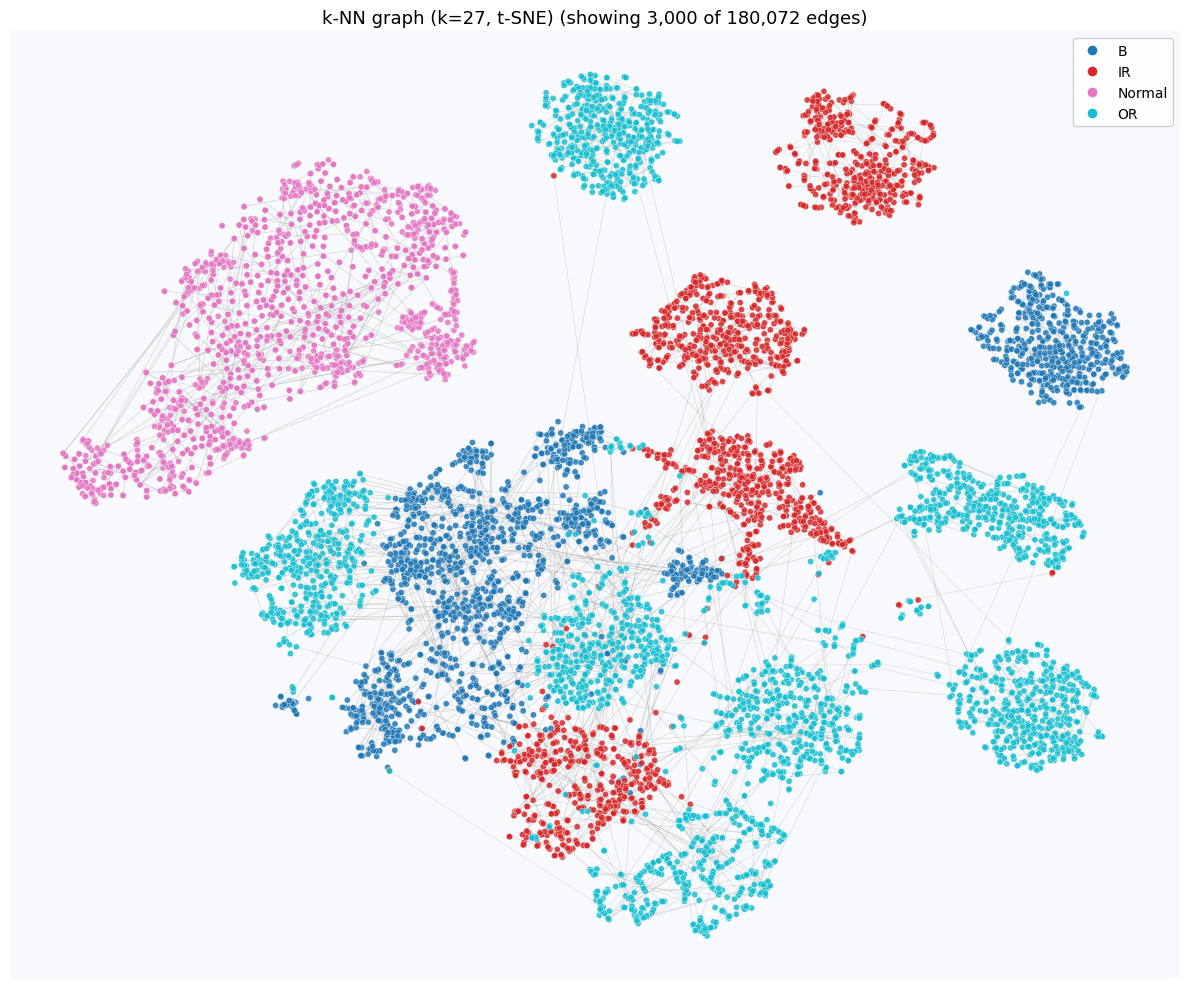

In [4]:
# ── (Optional) Visualize k-NN graph ──────────────────────────────────────────
fig = visualize_knn_graph(X_scaled, y, target_names=list(target_names),
                          n_neighbors=cfg.graph.n_neighbors)
plt.show()

ExperimentResults(epsilons=[0.05, 0.1, 0.2, 0.5, 1.0, 2.0], f1_range=[0.564, 0.924])


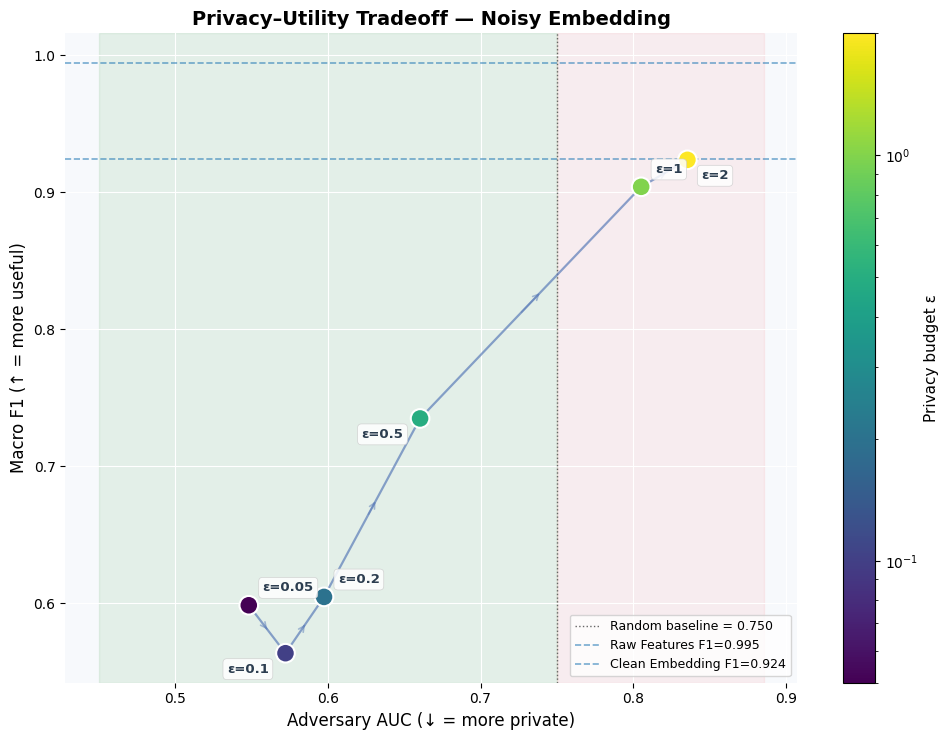

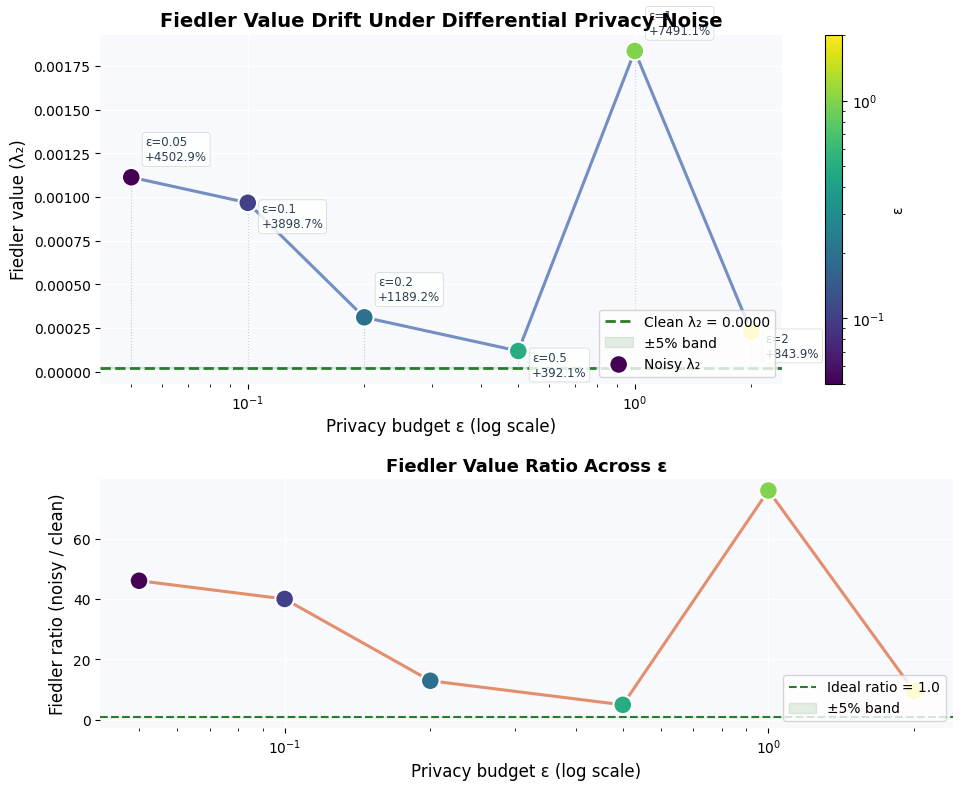

In [5]:
# ── Run epsilon sweep → ExperimentResults ─────────────────────────────────────
# Sweeps all epsilons from experiment.yaml; saves CSVs + figures/
results: ExperimentResults = experiment.run(X_scaled, y, target_names)
print(results)   # ExperimentResults(epsilons=[...], f1_range=[..., ...])

In [6]:
# ── Inspect typed results ─────────────────────────────────────────────────────

# EpsilonRecord — one per ε, full attribute access
rec: EpsilonRecord = results.records[-1]   # highest ε (least noise)
print(f"ε={rec.epsilon}  macro_f1={rec.macro_f1:.4f}  adv_auc={rec.adv_auc:.4f}")
print(f"  privacy_gain={rec.privacy_gain:+.4f}  random_baseline={rec.random_baseline:.4f}")
print(f"  fiedler: {rec.fiedler_clean:.4f} → {rec.fiedler_noisy:.4f}  (ratio {rec.fiedler_ratio:.4f})")
print()

# BaselineRecord — unperturbed reference stages
for br in results.baseline_records:
    print(f"{br.stage:<20}  F1={br.macro_f1:.4f}  adv_auc={br.adv_auc:.4f}")
print()

# DataFrame view (lazy property — built on demand)
results.metrics_df

ε=2.0  macro_f1=0.9238  adv_auc=0.8354
  privacy_gain=-0.0363  random_baseline=0.7500
  fiedler: 0.0000 → 0.0002  (ratio 9.4386)

Raw Features          F1=0.9946  adv_auc=0.9986
Clean Embedding       F1=0.9244  adv_auc=0.8157



,epsilon,macro_f1,adv_auc,adv_accuracy,privacy_gain,random_baseline,noise_scale,spectral_gap,noise_to_gap,fiedler_clean,fiedler_noisy,fiedler_ratio
0,0.05,0.5986,0.548325,0.61330,0.136650,0.750025,0.406860,0.00049,830.075078,0.000024,0.001114,46.028641
1,0.10,0.5636,0.572350,0.58305,0.166925,0.750025,0.203430,0.00049,415.037539,0.000024,0.000968,39.986807
2,0.20,0.6047,0.597575,0.61230,0.137700,0.750025,0.101715,0.00049,207.518769,0.000024,0.000312,12.891733
3,0.50,0.7350,0.660450,0.65910,0.090875,0.750025,0.040686,0.00049,83.007508,0.000024,0.000119,4.920627
4,1.00,0.9041,0.805150,0.79150,-0.041550,0.750025,0.020343,0.00049,41.503754,0.000024,0.001837,75.910646
5,2.00,0.9238,0.835400,0.78625,-0.036250,0.750025,0.010172,0.00049,20.751877,0.000024,0.000228,9.438592


In [7]:
# ── Inspect noise metadata for one epsilon ────────────────────────────────────
# Run a single forward pass to see the typed SpectralGapMetadata
mechanism = build_noise_mechanism(
    cfg.noise.mechanism, epsilon=cfg.noise.epsilons[2],  # mid-range ε
    **cfg.noise.params,
)
model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    noise_mechanism=mechanism,
    normalized=cfg.graph.normalized,
)
result: EmbeddingResult = model.fit_transform(X_scaled)
print(result)
print()

meta = result.noise_metadata
print(f"Mechanism type : {meta.type}")
print(f"Noise scale    : {meta.scale:.6f}")
print(f"Spectral gap   : {meta.gap:.6f}")
print(f"Noise/gap ratio: {meta.noise_to_gap:.4f}")
print(f"Fiedler clean  : {meta.fiedler_gap_clean:.6f}")
print(f"Fiedler noisy  : {meta.fiedler_gap_noisy:.6f}")
print(f"Fiedler ratio  : {meta.fiedler_gap_ratio:.4f}")

EmbeddingResult(samples=8767, components=4, fiedler_clean=0.000024, fiedler_noisy=0.000312, mechanism='spectral_gap')

Mechanism type : spectral_gap
Noise scale    : 0.101715
Spectral gap   : 0.000490
Noise/gap ratio: 207.5188
Fiedler clean  : 0.000024
Fiedler noisy  : 0.000312
Fiedler ratio  : 12.8917


In [8]:
# ── Inspect AttackResult ──────────────────────────────────────────────────────
avg_atk, per_class_atk = run_attack_all_classes(
    result.embedding_noisy, y, list(target_names),
    cv=cfg.evaluation.n_splits, random_state=cfg.evaluation.random_state,
)
print("Class-averaged attack result:")
print(avg_atk)
print(f"  adv_auc        = {avg_atk.adv_auc:.4f}")
print(f"  random_baseline= {avg_atk.random_baseline:.4f}")
print(f"  privacy_gain   = {avg_atk.privacy_gain:+.4f}")
print(f"  is_private     = {avg_atk.is_private}")
print()
display(avg_atk.to_frame())
print()
print("Per-class:")
for cls, atk in zip(target_names, per_class_atk):
    print(f"  {cls}: {atk}")

Class-averaged attack result:
AttackResult(adv_auc=0.5976, priv_gain=+0.1377, status='private')
  adv_auc        = 0.5976
  random_baseline= 0.7500
  privacy_gain   = +0.1377
  is_private     = True



,Adv Accuracy,Random Baseline,Privacy Gain,Norm Gain,Adv F1,Adv AUC
Logistic Regression (LR),0.6123,0.750025,0.1377,-0.661925,0.41715,0.597575



Per-class:
  B: AttackResult(adv_auc=0.6419, priv_gain=+0.1355, status='private')
  IR: AttackResult(adv_auc=0.5386, priv_gain=+0.2619, status='private')
  Normal: AttackResult(adv_auc=0.5918, priv_gain=+0.1517, status='private')
  OR: AttackResult(adv_auc=0.6180, priv_gain=+0.0017, status='private')


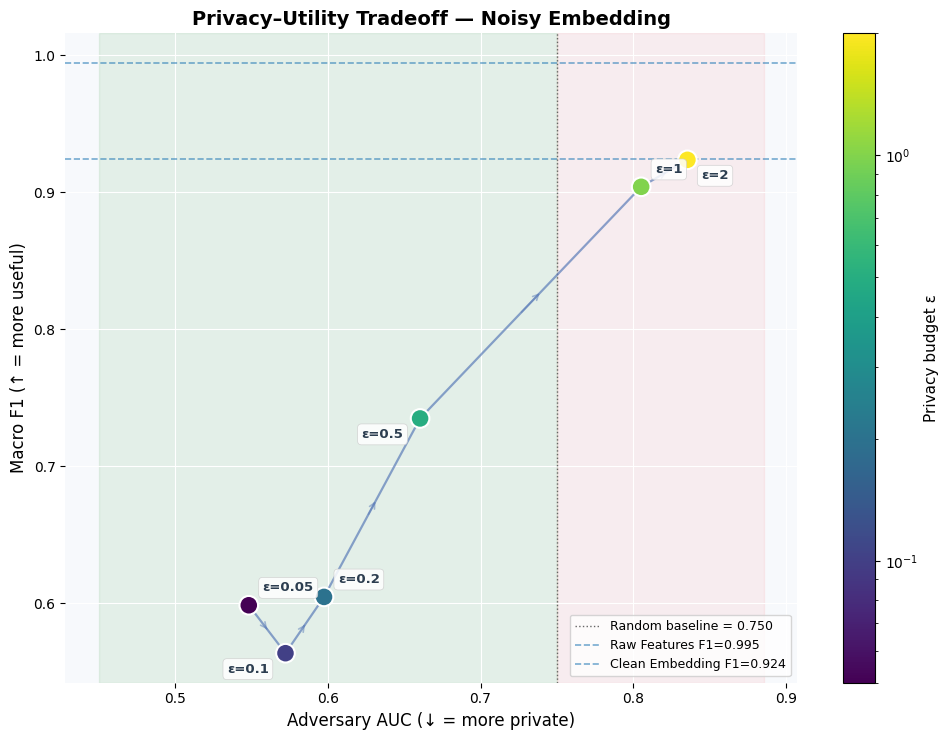

In [9]:
# ── Privacy–utility tradeoff ──────────────────────────────────────────────────
fig = plot_privacy_utility_tradeoff(
    results.records,                        # list[EpsilonRecord]
    baseline_records=results.baseline_records,  # list[BaselineRecord]
)
plt.show()

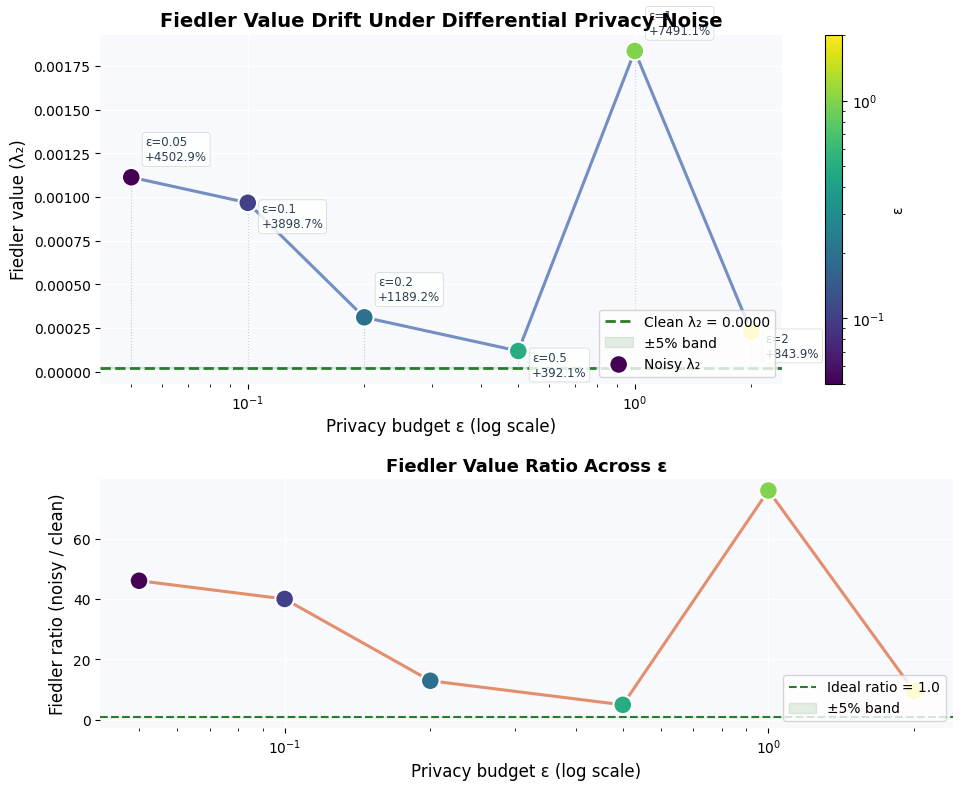

In [10]:
# ── Fiedler gap evolution ─────────────────────────────────────────────────────
fig = plot_fiedler_evolution(results.fiedler_records)  # list[FiedlerRecord]
plt.show()

In [11]:
# ── Deep-dive: classification on clean embedding ──────────────────────────────
clean_model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    normalized=cfg.graph.normalized,
)
clean: EmbeddingResult = clean_model.fit_transform(X_scaled)
print(clean)

clf_res: dict[str, ClassifierResult] = run_classification(
    clean.embedding_clean, y, target_names,   # attribute access, not string key
    cv=cfg.evaluation.n_splits,
)
print(f"\nRandom Forest  macro_f1={clf_res['Random Forest'].macro_f1:.4f}")
print(f"SVM            macro_f1={clf_res['SVM'].macro_f1:.4f}")
print()
display_classification_results(clf_res)

EmbeddingResult(samples=8767, components=4, fiedler_clean=0.000024, fiedler_noisy=0.000024, mechanism='none')

Random Forest  macro_f1=0.9225
SVM            macro_f1=0.7111



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.924,0.927,0.926,0.927
1,Random Forest,0.918,0.925,0.920,0.922
4,Decision Tree,0.897,0.903,0.901,0.902
2,SVM,0.730,0.820,0.728,0.711
0,Logistic Regression,0.572,0.867,0.497,0.465


## Three-Way Pipeline Comparison

Compare noise injected at three different stages:
- **Laplacian-space** — perturb L before eigendecomposition (existing)
- **Feature-space** — perturb raw features X before graph construction
- **Embedding-space** — perturb eigenvectors V after Laplacian Eigenmaps

All pipelines share the same ε sweep, snr_target, classifiers, and inference-attack mechanism.

In [12]:
from privacy_pipeline import (
    ComparisonExperiment, ComparisonResults, ComparisonRecord, PipelineMetrics,
    plot_pipeline_comparison, plot_comparison_tradeoff,
    FeatureSpaceNoisePipeline, EmbeddingSpaceNoisePipeline,
)

# ComparisonExperiment reads the same experiment.yaml
cmp_exp = ComparisonExperiment(cfg)
print(cmp_exp.cfg.noise.epsilons)

[0.05, 0.1, 0.2, 0.5, 1.0, 2.0]



── ε = 0.05 ─────────────────────────────
[FeatureNoise ε=0.05] fiedler 2.4201e-05→6.5001e-01 | 105.44s
[EmbeddingNoise ε=0.05] fiedler 2.4201e-05 (L unchanged) | 2.47s
  lap  → F1=0.5986  AUC=0.5483
  feat → F1=0.2352  AUC=0.4929
  emb  → F1=0.2372  AUC=0.5079

── ε = 0.1 ─────────────────────────────
[FeatureNoise ε=0.1] fiedler 2.4201e-05→6.4988e-01 | 101.85s
[EmbeddingNoise ε=0.1] fiedler 2.4201e-05 (L unchanged) | 2.57s
  lap  → F1=0.5614  AUC=0.5723
  feat → F1=0.2328  AUC=0.4977
  emb  → F1=0.2396  AUC=0.5166

── ε = 0.2 ─────────────────────────────
[FeatureNoise ε=0.2] fiedler 2.4201e-05→6.4663e-01 | 121.44s
[EmbeddingNoise ε=0.2] fiedler 2.4201e-05 (L unchanged) | 2.63s
  lap  → F1=0.6060  AUC=0.5976
  feat → F1=0.2379  AUC=0.5277
  emb  → F1=0.2460  AUC=0.5369

── ε = 0.5 ─────────────────────────────
[FeatureNoise ε=0.5] fiedler 2.4201e-05→4.3145e-01 | 93.79s
[EmbeddingNoise ε=0.5] fiedler 2.4201e-05 (L unchanged) | 2.23s
  lap  → F1=0.7358  AUC=0.6604
  feat → F1=0.3632  

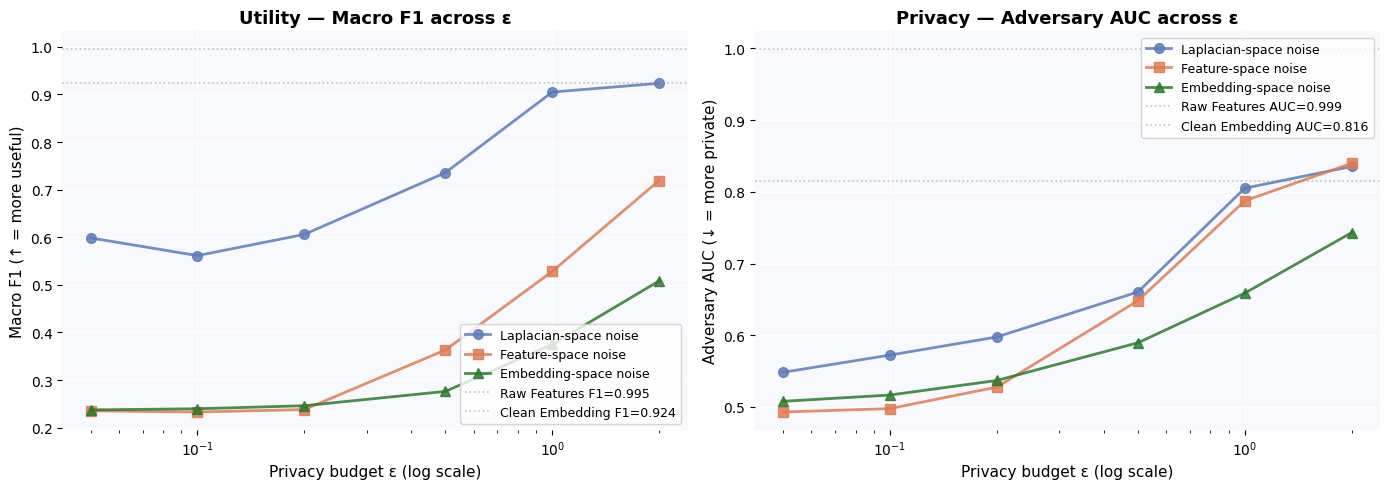

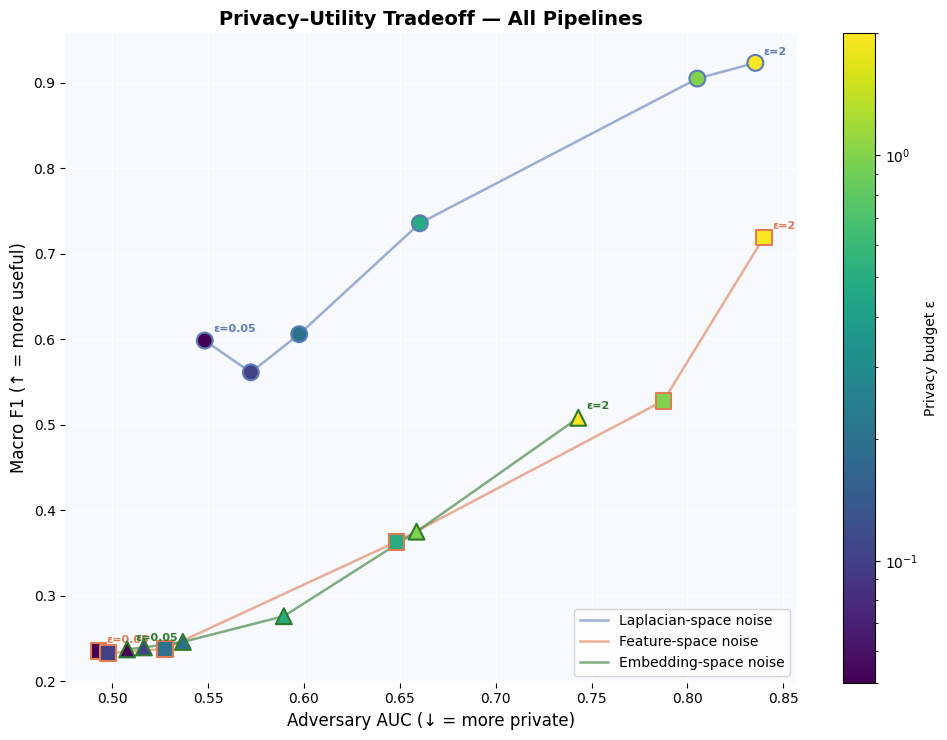

In [13]:
# ── Run three-way comparison sweep ────────────────────────────────────────────
# Uses X_scaled, y, target_names already loaded above
cmp_results: ComparisonResults = cmp_exp.run(X_scaled, y, target_names)
print(cmp_results)

In [14]:
# ── Inspect a single ComparisonRecord ─────────────────────────────────────────
rec: ComparisonRecord = cmp_results.records[-1]   # highest ε (least noise)
print(f"ε = {rec.epsilon}")
print(f"  Laplacian  F1={rec.laplacian.macro_f1:.4f}  AUC={rec.laplacian.adv_auc:.4f}  priv_gain={rec.laplacian.privacy_gain:+.4f}")
print(f"  Feature    F1={rec.feature.macro_f1:.4f}  AUC={rec.feature.adv_auc:.4f}  priv_gain={rec.feature.privacy_gain:+.4f}")
print(f"  Embedding  F1={rec.embedding.macro_f1:.4f}  AUC={rec.embedding.adv_auc:.4f}  priv_gain={rec.embedding.privacy_gain:+.4f}")

ε = 2.0
  Laplacian  F1=0.9235  AUC=0.8354  priv_gain=-0.0363
  Feature    F1=0.7192  AUC=0.8398  priv_gain=-0.0412
  Embedding  F1=0.5082  AUC=0.7431  priv_gain=+0.0560


In [15]:
# ── Long-format DataFrame (one row per ε × pipeline) ──────────────────────────
cmp_results.long_df

,epsilon,pipeline,macro_f1,adv_auc,adv_accuracy,privacy_gain,random_baseline,fiedler_clean,fiedler_noisy
0,0.05,laplacian,0.5986,0.548325,0.613300,0.136650,0.750025,0.000024,0.001114
1,0.05,feature,0.2352,0.492950,0.500900,0.249125,0.750025,0.000024,0.650011
2,0.05,embedding,0.2372,0.507875,0.511575,0.238400,0.750025,0.000024,0.000024
3,0.10,laplacian,0.5614,0.572350,0.583050,0.166925,0.750025,0.000024,0.000968
4,0.10,feature,0.2328,0.497675,0.503975,0.246025,0.750025,0.000024,0.649880
5,0.10,embedding,0.2396,0.516600,0.517200,0.232800,0.750025,0.000024,0.000024
6,0.20,laplacian,0.6060,0.597575,0.612300,0.137700,0.750025,0.000024,0.000312
7,0.20,feature,0.2379,0.527700,0.521225,0.228775,0.750025,0.000024,0.646629
8,0.20,embedding,0.2460,0.536925,0.532100,0.217875,0.750025,0.000024,0.000024
9,0.50,laplacian,0.7358,0.660450,0.659100,0.090875,0.750025,0.000024,0.000119


In [16]:
# ── Wide-format DataFrame (one row per ε) ──────────────────────────────────────
cmp_results.wide_df

,epsilon,lap_f1,lap_auc,lap_priv_gain,feat_f1,feat_auc,feat_priv_gain,emb_f1,emb_auc,emb_priv_gain
0,0.05,0.5986,0.548325,0.136650,0.2352,0.492950,0.249125,0.2372,0.507875,0.238400
1,0.10,0.5614,0.572350,0.166925,0.2328,0.497675,0.246025,0.2396,0.516600,0.232800
2,0.20,0.6060,0.597575,0.137700,0.2379,0.527700,0.228775,0.2460,0.536925,0.217875
3,0.50,0.7358,0.660450,0.090875,0.3632,0.648275,0.108500,0.2761,0.589550,0.178100
4,1.00,0.9051,0.805150,-0.041550,0.5283,0.787550,-0.012700,0.3750,0.658750,0.119750
5,2.00,0.9235,0.835400,-0.036250,0.7192,0.839800,-0.041200,0.5082,0.743100,0.056000


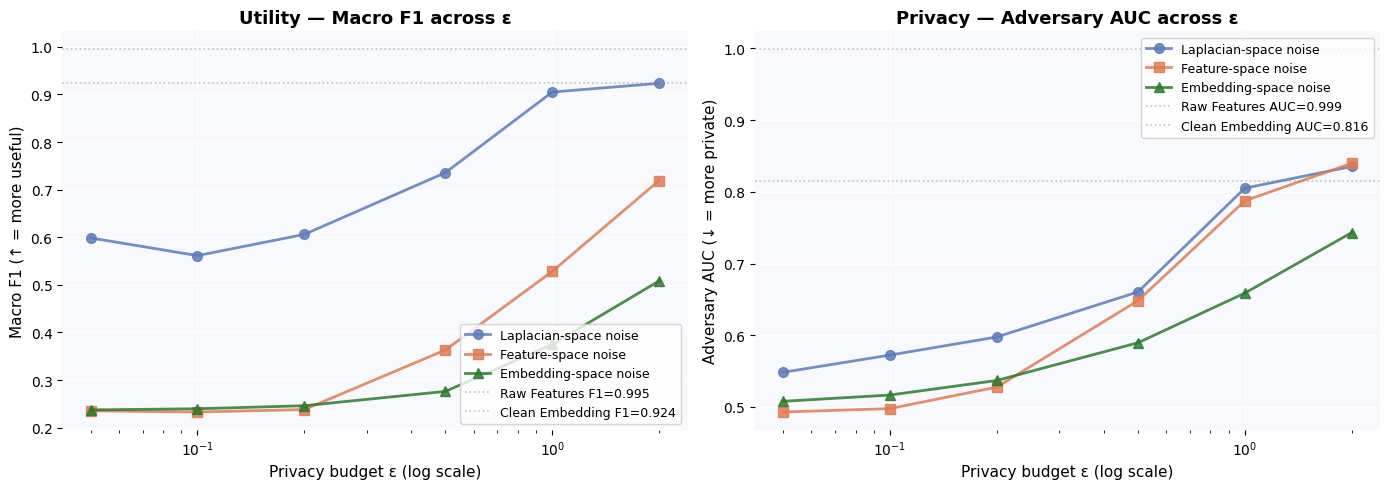

In [17]:
# ── F1 and AUC line plots across ε ────────────────────────────────────────────
fig = plot_pipeline_comparison(cmp_results)
plt.show()

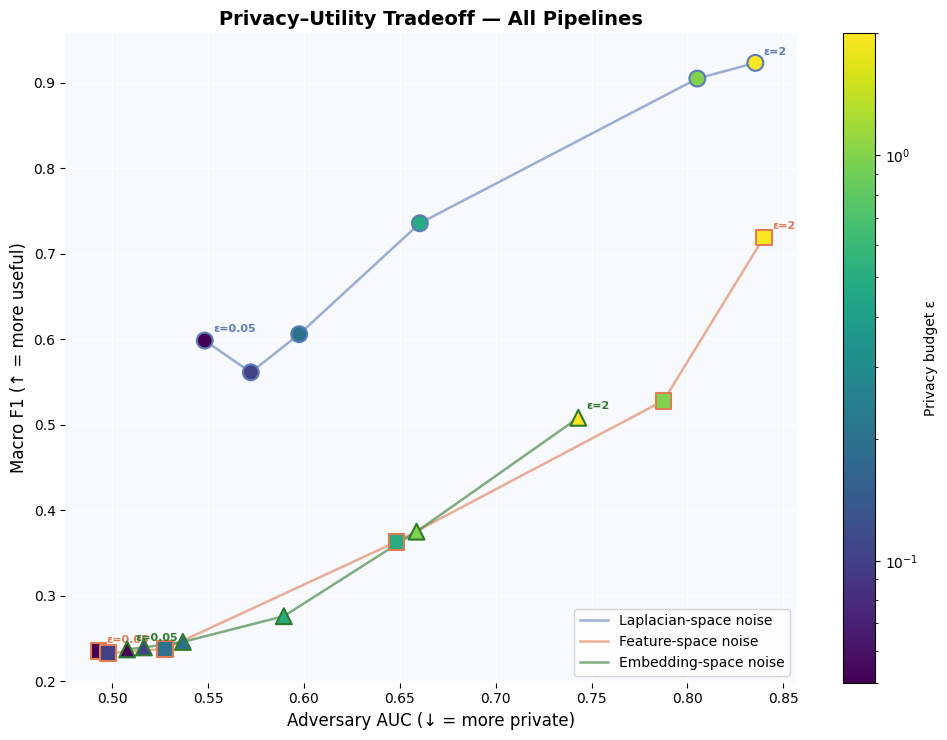

In [18]:
# ── Privacy–utility scatter: all three trajectories ───────────────────────────
fig = plot_comparison_tradeoff(cmp_results)
plt.show()